In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
iris=load_iris()

In [3]:
df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
df['species']=iris.target

In [4]:
df['species']=iris.target

In [5]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [6]:
df=df[df['species']!=0][['sepal width (cm)','petal length (cm)','species']]

In [7]:
df

,sepal width (cm),petal length (cm),species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1
...,...,...,...
145,3.0,5.2,2
146,2.5,5.0,2
147,3.0,5.2,2
148,3.4,5.4,2


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt



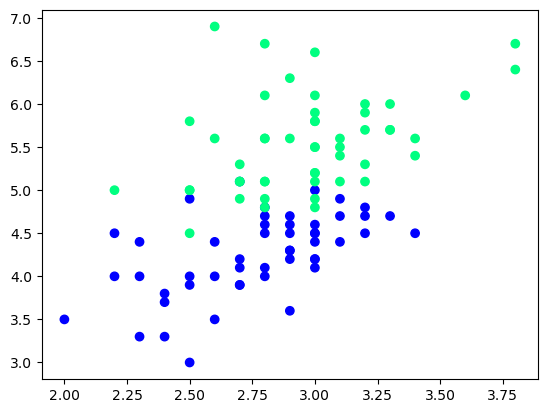

In [9]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['species'],cmap='winter')

In [10]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [11]:
df.size

300

In [12]:
df.shape

(100, 3)

In [13]:
df_train.shape

(10, 3)

In [14]:
df_val.shape

(5, 3)

In [15]:
df_test.shape

(5, 3)

In [16]:
X_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

<h3>case 1-bagging</h3>
    

In [17]:
X_test

array([[2.3, 3.3],
       [2.8, 5.1],
       [2.5, 3. ],
       [3. , 4.8],
       [3. , 5.8]])

In [18]:
y_test

array([1, 2, 1, 2, 2])

In [19]:
# df=df.sample(100)
# df_train=df.iloc[:60,:].sample(10)
# df_val=df.iloc[60:80,:].sample(5)
# df_test=df.iloc[80:,:].sample(5)

#data for tree1 
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

In [20]:
df_bag

,sepal width (cm),petal length (cm),species
122,2.8,6.7,2
56,3.3,4.7,1
84,3.0,4.5,1
123,2.7,4.9,2
51,3.2,4.5,1
145,3.0,5.2,2
120,3.2,5.7,2
122,2.8,6.7,2


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score


In [23]:
dt_bag1=DecisionTreeClassifier()

In [24]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf=clf,legend=2)
    y_pred=clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))



# Values of legend
# Value	Meaning
# 0	No legend
# 1	Legend at upper right
# 2	Legend at lower left
# 3	Legend at upper left

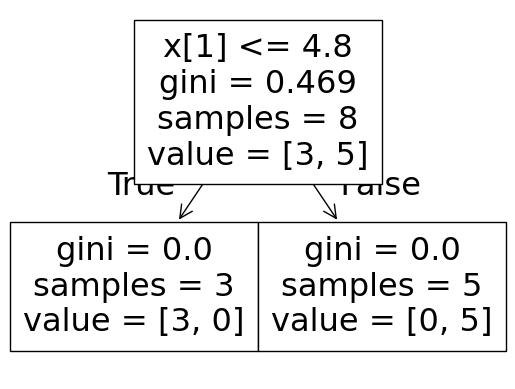

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


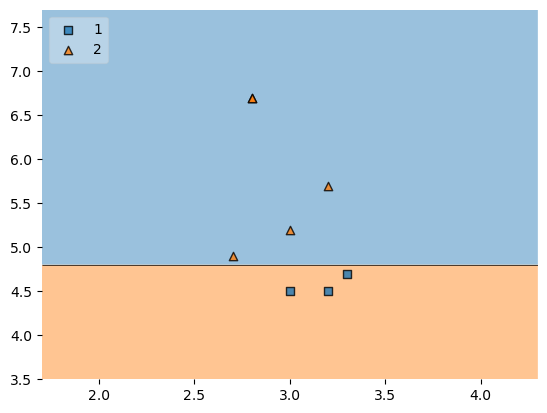

In [25]:
evaluate(dt_bag1,X,y)

In [26]:
#df_bag1
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal width (cm),petal length (cm),species
123,2.7,4.9,2
122,2.8,6.7,2
124,3.3,5.7,2
56,3.3,4.7,1
56,3.3,4.7,1
84,3.0,4.5,1
123,2.7,4.9,2
124,3.3,5.7,2


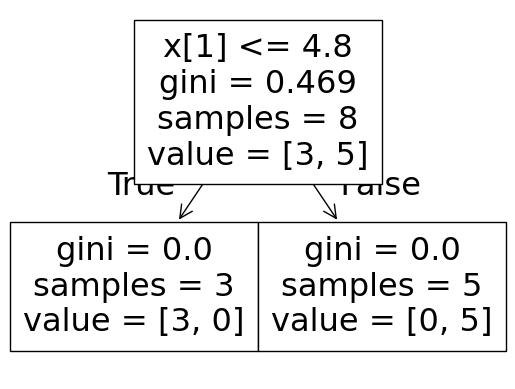

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


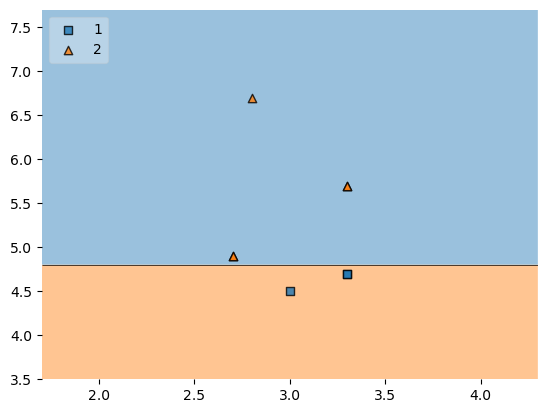

In [27]:
dt_bag2=DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [28]:
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

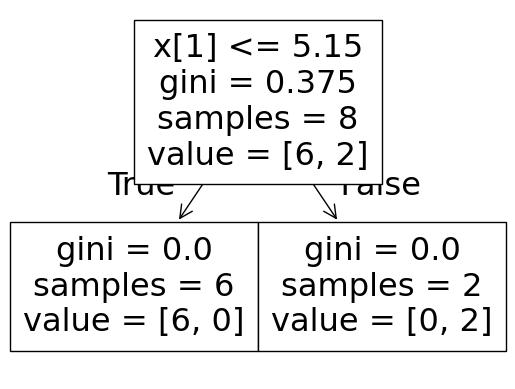

C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


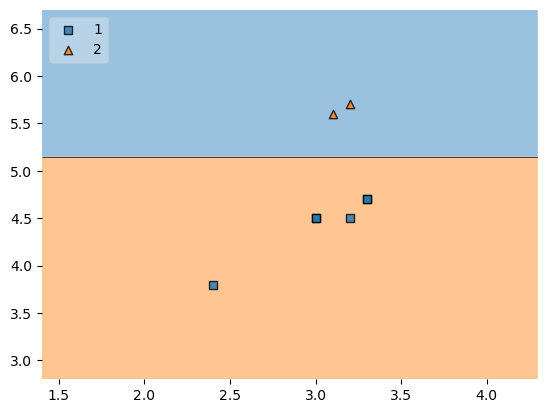

In [29]:
dt_bag3=DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

<h3>Predict</h3>

In [30]:
df_test

,sepal width (cm),petal length (cm),species
75,3.0,4.4,1
53,2.3,4.0,1
61,3.0,4.2,1
91,3.0,4.6,1
99,2.8,4.1,1


In [31]:
print(dt_bag1.predict(np.array([3.0,4.4]).reshape(1,2)))
print(dt_bag2.predict(np.array([3.0,4.4]).reshape(1,2)))
print(dt_bag3.predict(np.array([3.0,4.4]).reshape(1,2)))

[1]
[1]
[1]


C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\TANUSHREE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<h3>PASTING</h3>

In [32]:
#ROW SAMPLING WITHOUT REPLACEMENT
df_train

,sepal width (cm),petal length (cm),species
80,2.4,3.8,1
124,3.3,5.7,2
140,3.1,5.6,2
51,3.2,4.5,1
123,2.7,4.9,2
56,3.3,4.7,1
145,3.0,5.2,2
122,2.8,6.7,2
84,3.0,4.5,1
120,3.2,5.7,2


In [33]:
df_train.sample(8)

,sepal width (cm),petal length (cm),species
123,2.7,4.9,2
51,3.2,4.5,1
124,3.3,5.7,2
56,3.3,4.7,1
80,2.4,3.8,1
145,3.0,5.2,2
120,3.2,5.7,2
140,3.1,5.6,2


<h3>RANDOM SUBSPACES

In [34]:
#HERE WE DO COLUMN SAMPLING with or without replacementdf.sample()
df

,sepal width (cm),petal length (cm),species
83,2.7,5.1,1
76,2.8,4.8,1
50,3.2,4.7,1
81,2.4,3.7,1
132,2.8,5.6,2
...,...,...,...
119,2.2,5.0,2
85,3.4,4.5,1
66,3.0,4.5,1
92,2.6,4.0,1


In [48]:
df1=df.sample(2,replace=True,axis=1)# 2 columns ,with replacement,columns axis=1

In [49]:
df1

,sepal width (cm),species
83,2.7,1
76,2.8,1
50,3.2,1
81,2.4,1
132,2.8,2
...,...,...
119,2.2,2
85,3.4,1
66,3.0,1
92,2.6,1


<h3>RANDOM PATCHES

In [50]:
df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
df['species']=iris.target

In [51]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [54]:
df.sample(8,replace=True).sample(2,replace=True,axis=1)#both row and column sampling

,sepal width (cm),sepal length (cm)
88,3.0,5.6
132,2.8,6.4
122,2.8,7.7
128,2.8,6.4
110,3.2,6.5
145,3.0,6.7
124,3.3,6.7
35,3.2,5.0
